In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import plotly.graph_objects as go
import itertools
from scipy.signal import find_peaks
from matplotlib import pyplot as plt
from matplotlib.legend_handler import HandlerLine2D
from scipy import stats 
from scipy.stats import weibull_min

%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 10, 6

import reliability.Fitters as rf

In [2]:
wave_data_swell = pd.read_csv('hs_swell_1940-2025.csv') 
wave_data_windsea = pd.read_csv('hs_windsea_1940-2025.csv')
wave_data = pd.read_csv('hs_1940-2025.csv')
wave_data_windsea['time'] = pd.to_datetime(wave_data_windsea['time'], unit='s').dt.year + (pd.to_datetime(wave_data_windsea['time'], unit='s').dt.dayofyear - 1) / 365.25
wave_data_swell['time'] = pd.to_datetime(wave_data_swell['time'], unit='s').dt.year + (pd.to_datetime(wave_data_swell['time'], unit='s').dt.dayofyear - 1) / 365.25
wave_data['time'] = pd.to_datetime(wave_data['time'], unit='s').dt.year + (pd.to_datetime(wave_data['time'], unit='s').dt.dayofyear - 1) / 365.25
wave_data_swell.head()

,time,Hs,Tp,datetime
0,1940,0.332642,3.30405,1940-01-01 00:00:00
1,1940,0.278931,2.84165,1940-01-01 06:00:00
2,1940,0.315308,2.71421,1940-01-01 12:00:00
3,1940,0.300659,2.58335,1940-01-01 18:00:00
4,1940,0.165894,2.80357,1940-01-02 00:00:00


In [3]:
# Hs_99

Hs_99_swell = wave_data_swell['Hs'].quantile(0.99)
Hs_99_windsea = wave_data_windsea['Hs'].quantile(0.99)
Hs_comb = wave_data['Hs'].quantile(0.99)

print('99th percentile of Hs (Swell only):', Hs_99_swell)
print('99th percentile of Hs (Windsea only):', Hs_99_windsea)
print('99th percentile of Hs (Combined):', Hs_comb)

99th percentile of Hs (Swell only): 0.5183125120401382
99th percentile of Hs (Windsea only): 1.6135254
99th percentile of Hs (Combined): 1.6267458343505854


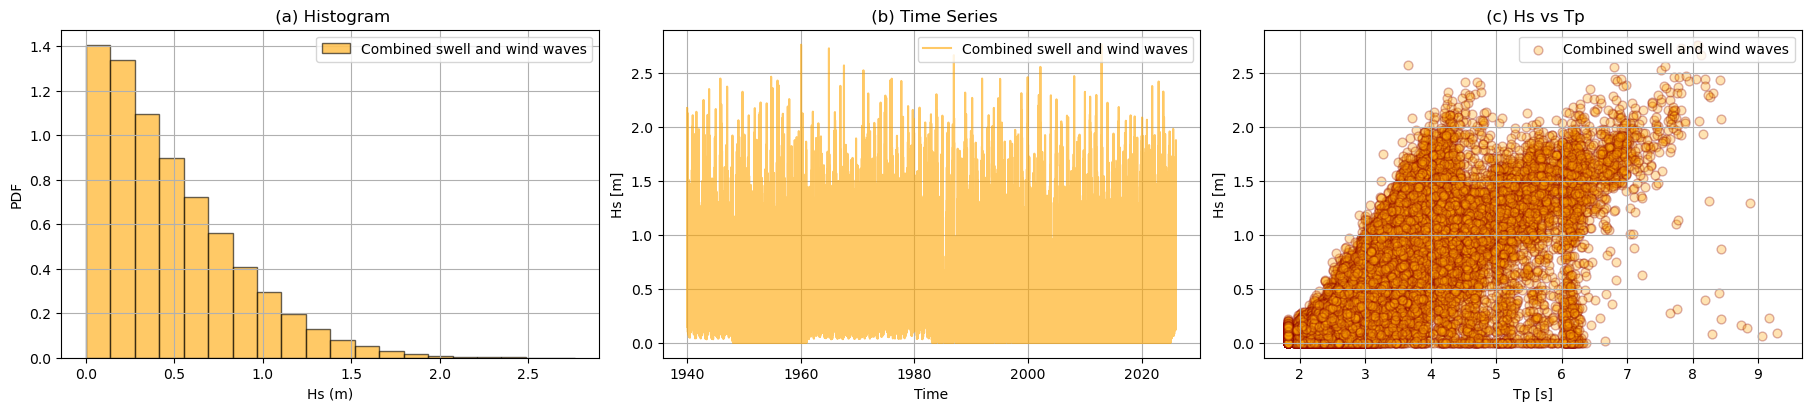

In [ ]:


fig, ax = plt.subplots(1, 3, figsize=(18, 4), layout='constrained')
ax[0].set_xlabel('Hs (m)')
ax[0].set_ylabel('PDF')
#ax[0].hist(wave_data_swell['Hs'], bins=20, color='cornflowerblue', edgecolor='black', alpha=0.6, histtype='bar', density=True, label= 'Swell only')
ax[0].hist(wave_data['Hs'], bins=20, color='orange', edgecolor='black', alpha=0.6, histtype='bar', density=True, label= 'Combined swell and wind waves')
#ax[0].hist(wave_data_windsea['Hs'], bins=20, color='green', edgecolor='black', alpha=0.6, histtype='bar', density=True, label= 'Windsea only')
ax[0].grid()
ax[0].set_title(' (a) Histogram')
ax[0].legend(loc='upper right');

#ax[1].plot(wave_data_swell['time'], wave_data_swell['Hs'], alpha=0.6, color='cornflowerblue',label= 'Swell only')
ax[1].plot(wave_data['time'], wave_data['Hs'], alpha=0.6, color='orange', label= 'Combined swell and wind waves')
#ax[1].plot(wave_data_windsea['time'], wave_data_windsea['Hs'], alpha=0.3, color='green', label= 'Windsea only')
ax[1].set_title(' (b) Time Series')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Hs [m]')
ax[1].legend(loc='upper right')
ax[1].grid();

#ax[2].scatter(wave_data_swell['Tp'], wave_data_swell['Hs'], s=40, color='cornflowerblue', alpha=0.6, edgecolors='darkblue', label= 'Swell only')
ax[2].scatter(wave_data['Tp'], wave_data['Hs'], s=40, color='orange', alpha=0.3, edgecolors='darkred', label= 'Combined swell and wind waves')
#ax[2].scatter(wave_data_windsea['Tp'], wave_data_windsea['Hs'], s=40, color='green', alpha=0.3, edgecolors='darkgreen', label= 'Windsea only')
#ax[2].scatter(Hs_99['Tp'], Hs_99['Hs'], 40,'r', label='Hs > 99th percentile')
#ax[2].axhline(y=threshold, color='k', linestyle='--', label=f'th={threshold:.3f}m')
ax[2].set_xlabel('Tp [s]')
ax[2].set_ylabel('Hs [m]')
ax[2].legend(loc='upper right')
ax[2].set_title(' (c) Hs vs Tp')
ax[2].grid();
